In [2]:
import pandas as pd
import numpy as np

In [3]:
### read the raw data file
df = pd.read_csv("../../data/processed/aurora_clean.csv")
df.head(10)


,raw_row_num,obs_id,activities_id,height_id,sky_id,observer_id,timestamp,address_country,address_state,location,...,bz_gsm,sigma_bz_gsm,cloud_cover,visibility,moon_phase,moon_darkness,abs_mlat,mlt_sin,mlt_cos,sun_elev
0,1,7372c36fe0c7,NaN,NaN,NaN,117.0,2014-10-01 08:21:34.818216+00:00,United Arab Emirates,Dubai,SRID=4326;POINT (55.154846755193745 25.0416718...,...,-1.466667,1.200000,0.0,-1,0.252,0.497,19.985358,-0.033908,-0.999425,62.114843
1,3,07c100d1ef09,NaN,NaN,clea,NaN,2014-10-02 13:47:29.552583+00:00,United States,NM,SRID=4326;POINT (-106.31864826448822 35.874131...,...,-0.966667,1.566667,1.0,-1,0.286,0.429,44.155324,0.993403,-0.114675,8.246665
2,15,6fd8a95564f0,NaN,NaN,NaN,NaN,2014-10-22 01:10:40.044918+00:00,Antarctica,NaN,SRID=4326;POINT (-135.09297894447892 -82.87975...,...,-1.733333,2.200000,64.0,-1,0.963,0.926,71.928091,-0.859003,0.511971,13.679165
3,16,bc046b0aa4df,NaN,NaN,NaN,140.0,2014-10-22 19:06:17.624720+00:00,United States,NM,SRID=4326;POINT (-106.31916467073015 35.878203...,...,-1.000000,1.200000,60.0,-1,0.963,0.926,44.158024,0.128505,-0.991709,43.235276
4,17,4e1b62f5934a,NaN,NaN,NaN,NaN,2014-10-22 22:32:06.907449+00:00,Island,NaN,SRID=4326;POINT (-16.044471198100453 64.105858...,...,0.066667,0.666667,95.0,-1,0.963,0.926,63.637495,-0.451047,0.892500,-30.444553
5,18,a9509b429ef5,NaN,NaN,NaN,NaN,2014-10-22 22:33:03.386281+00:00,Island,NaN,SRID=4326;POINT (-16.017557191565377 64.113761...,...,0.066667,0.666667,95.0,-1,0.963,0.926,63.643014,-0.450637,0.892707,-30.447267
6,20,b5ffe350863a,NaN,NaN,clea,140.0,2014-10-26 03:19:21.325739+00:00,United States,NM,SRID=4326;POINT (-106.33003158628168 35.876309...,...,-2.733333,1.966667,1.0,-1,0.098,0.803,44.154061,-0.945273,0.326281,-27.354296
7,21,f88f2019ea9f,quie,n,NaN,140.0,2014-10-26 03:27:27.567488+00:00,United States,NM,SRID=4326;POINT (-106.2019892010742 35.8171703...,...,-2.733333,1.966667,1.0,-1,0.098,0.803,44.115885,-0.944343,0.328963,-27.462722
8,22,3cbae2892749,NaN,NaN,NaN,185.0,2014-10-27 20:05:23.397773+00:00,Sverige,Norrbottens län,SRID=4326;POINT (19.78205132279181 66.55501876...,...,-3.300000,2.833333,0.0,-1,0.132,0.736,63.636330,-0.499531,0.866296,-30.938045
9,23,481f607096bd,acti,over,NaN,185.0,2014-10-27 23:44:19.055780+00:00,Sverige,Norrbottens län,SRID=4326;POINT (19.79352323960399 66.60534808...,...,-4.766667,1.533333,0.0,-1,0.132,0.736,63.688283,0.369047,0.929411,-34.977684


In [4]:
df.columns

features=['abs_mlat', 'kp', 'bz_gsm', 'cloud_cover', 'moon_darkness', 'mlt_sin', 'mlt_cos', 'sun_elev']
target='see_aurora'

data = df[features + [target]].dropna()
X = data[features]
y = data[target]

## For data handling
import numpy as np

## For plotting
import matplotlib.pyplot as plt
from seaborn import set_style

## This sets the plot style
## to have a grid on a dark background
set_style("whitegrid")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA


pipe = Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=8))])

pipe.fit(X)

transformed_data = pipe.transform(X)









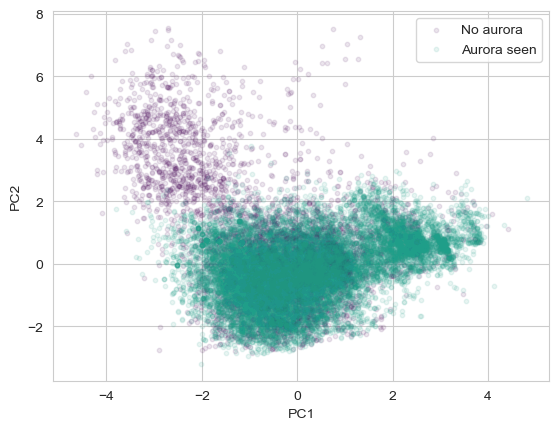

In [5]:
colors = {True: "#1f9e89", False: "#440154"}
labels = {True: "Aurora seen", False: "No aurora"}

for cls in [False, True]:
    mask = (y == cls)
    plt.scatter(transformed_data[mask, 0], transformed_data[mask, 1],
                c=colors[cls], label=labels[cls], alpha=0.1, s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

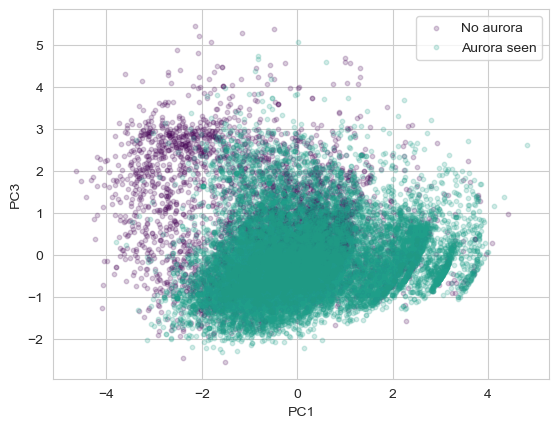

In [6]:
colors = {True: "#1f9e89", False: "#440154"}
labels = {True: "Aurora seen", False: "No aurora"}

for cls in [False, True]:
    mask = (y == cls)
    plt.scatter(transformed_data[mask, 0], transformed_data[mask, 2],
                c=colors[cls], label=labels[cls], alpha=0.2, s=10)

plt.xlabel("PC1")
plt.ylabel("PC3")
plt.legend()
plt.show()

In [7]:
pca = pipe.named_steps["pca"]         

pca.explained_variance_ratio_



array([0.24825224, 0.22060503, 0.12908968, 0.11884696, 0.11597606,
       0.09853903, 0.04112779, 0.02756322])

In [ ]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Scale and run PCA ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=5)
scores = pca.fit_transform(X_scaled)

print("Explained variance ratios:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.3f} ({ev*100:.1f} %)")
print(f"  Cumulative (PC1-5): {pca.explained_variance_ratio_.sum()*100:.1f} %")

# Loadings
loadings = pca.components_.T  # shape: (n_features, n_components)
feature_names = [f'Metabolite_{i+1}' for i in range(len(features))]

Explained variance ratios:
  PC1: 0.248 (24.8 %)
  PC2: 0.221 (22.1 %)
  PC3: 0.129 (12.9 %)
  PC4: 0.119 (11.9 %)
  PC5: 0.116 (11.6 %)
  Cumulative (PC1-5): 83.3 %


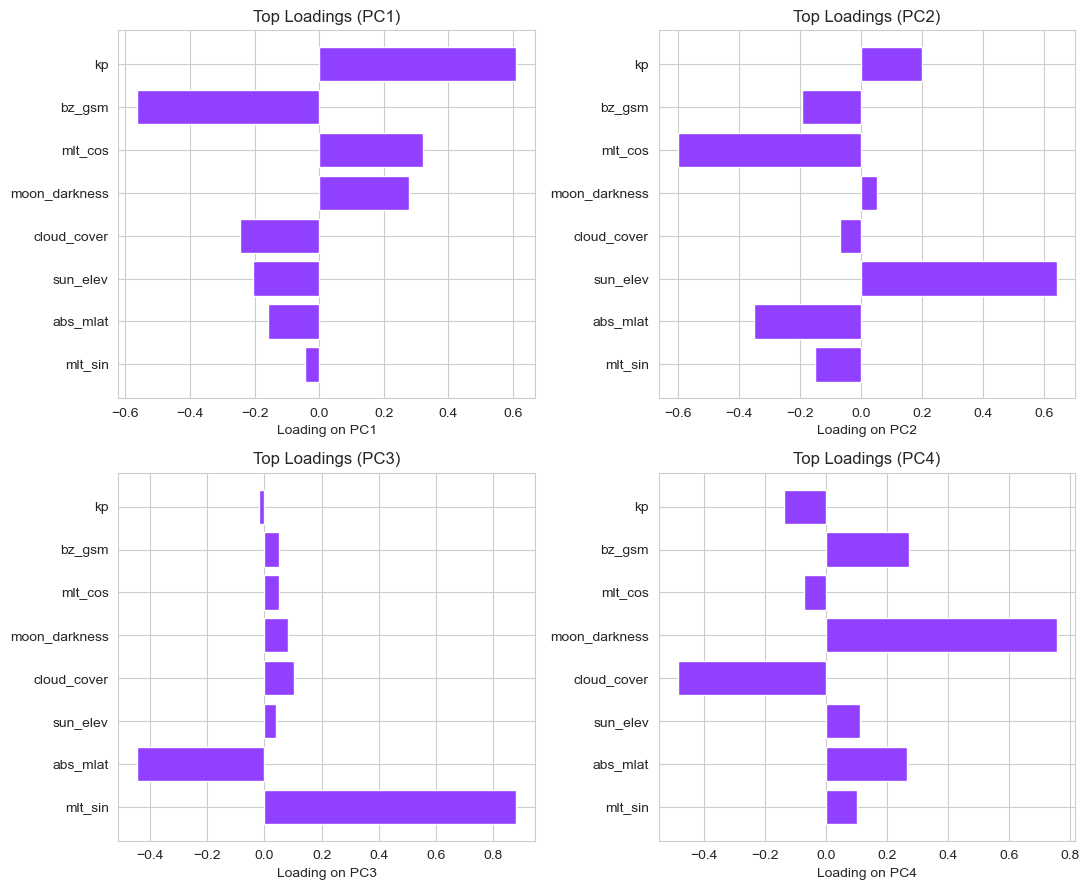

In [9]:


#code adapted from https://plotivy.app/techniques/pca-visualization


X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=5)
scores = pca.fit_transform(X_scaled)
loadings = pca.components_.T
feat_names = features
ev = pca.explained_variance_ratio_


fig, axes = plt.subplots(2, 2, figsize=(11, 9))

order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 0].barh(range(len(order)), loadings[order, 0], color='#9240ff')
axes[0, 0].set_yticks(range(len(order)))
axes[0, 0].set_yticklabels([feat_names[i] for i in order])
axes[0, 0].set_xlabel('Loading on PC1')
axes[0, 0].set_title('Top Loadings (PC1)')
axes[0, 0].invert_yaxis()


order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 1].barh(range(len(order)), loadings[order, 1], color='#9240ff')
axes[0, 1].set_yticks(range(len(order)))
axes[0, 1].set_yticklabels([feat_names[i] for i in order])
axes[0, 1].set_xlabel('Loading on PC2')
axes[0, 1].set_title('Top Loadings (PC2)')
axes[0, 1].invert_yaxis()

# 3. Loadings bar chart (PC3)
order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 0].barh(range(len(order)), loadings[order, 2], color='#9240ff')
axes[1, 0].set_yticks(range(len(order)))
axes[1, 0].set_yticklabels([feat_names[i] for i in order])
axes[1, 0].set_xlabel('Loading on PC3')
axes[1, 0].set_title('Top Loadings (PC3)')
axes[1, 0].invert_yaxis()

# 4. Loadings bar chart (PC4)
order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 1].barh(range(len(order)), loadings[order, 3], color='#9240ff')
axes[1, 1].set_yticks(range(len(order)))
axes[1, 1].set_yticklabels([feat_names[i] for i in order])
axes[1, 1].set_xlabel('Loading on PC4')
axes[1, 1].set_title('Top Loadings (PC4)')
axes[1, 1].invert_yaxis()


plt.tight_layout()
plt.savefig('pca_4panel.png', dpi=300, bbox_inches='tight')
plt.show()

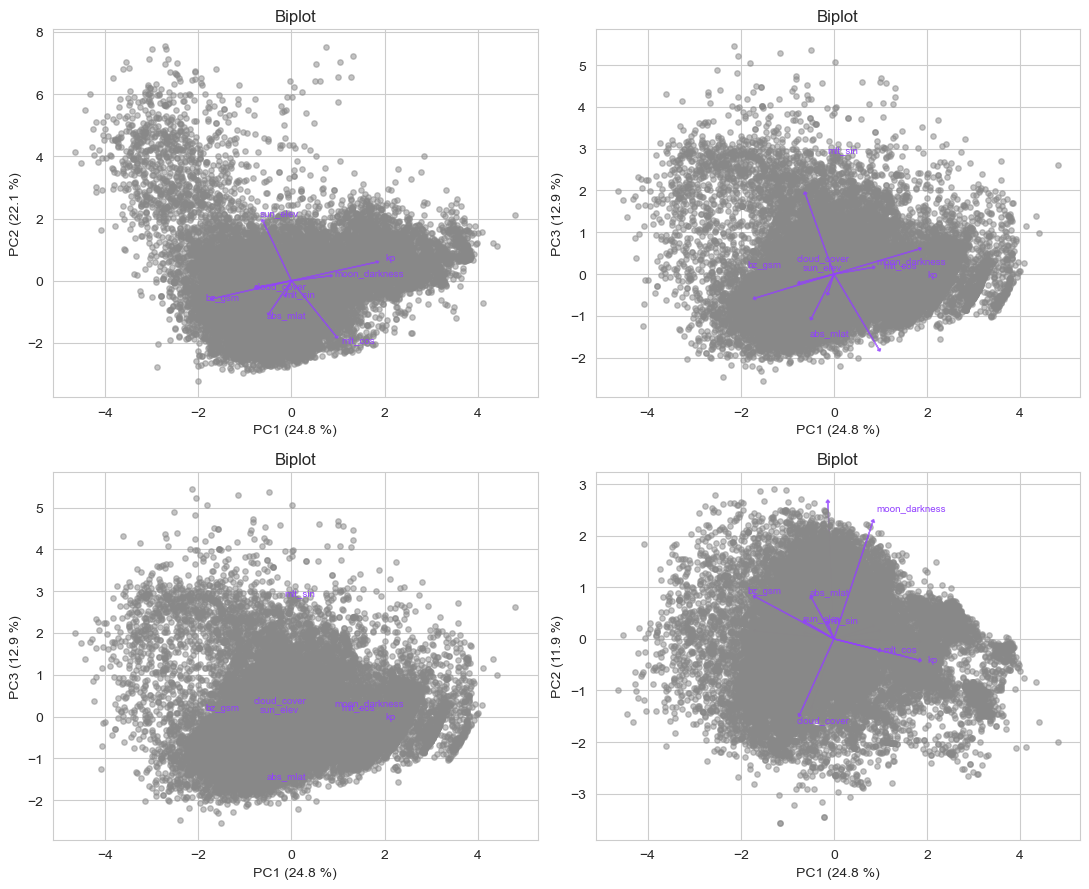

In [10]:
#code adapted from https://plotivy.app/techniques/pca-visualization


fig, axes = plt.subplots(2, 2, figsize=(11, 9))

order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 0].scatter(scores[:, 0], scores[:, 1], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[0, 0].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[0, 0].text(loadings[i, 0]*scale*1.1, loadings[i, 1]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[0, 0].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[0, 0].set_ylabel(f'PC2 ({ev[1]*100:.1f} %)')
axes[0, 0].set_title('Biplot')


order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[0, 1].scatter(scores[:, 0], scores[:, 2], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[0, 1].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[0, 1].text(loadings[i, 0]*scale*1.1, loadings[i, 2]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[0, 1].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[0, 1].set_ylabel(f'PC3 ({ev[2]*100:.1f} %)')
axes[0, 1].set_title('Biplot')

#
order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 0].scatter(scores[:, 0], scores[:, 2], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[1, 1].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 2]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[1, 0].text(loadings[i, 0]*scale*1.1, loadings[i, 2]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[1, 0].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[1, 0].set_ylabel(f'PC3 ({ev[2]*100:.1f} %)')
axes[1, 0].set_title('Biplot')


order = np.argsort(np.abs(loadings[:, 0]))[::-1][:10]
axes[1, 1].scatter(scores[:, 0], scores[:, 3], s=15, color='#888', alpha=0.5)
scale = 3
for i in range(min(8, len(feat_names))):
    axes[1, 1].arrow(0, 0, loadings[i, 0]*scale, loadings[i, 3]*scale,
                     head_width=0.08, head_length=0.05, fc='#9240ff',
                     ec='#9240ff', alpha=0.7)
    axes[1, 1].text(loadings[i, 0]*scale*1.1, loadings[i, 3]*scale*1.1,
                    feat_names[i], fontsize=7, color='#9240ff')
axes[1, 1].set_xlabel(f'PC1 ({ev[0]*100:.1f} %)')
axes[1, 1].set_ylabel(f'PC2 ({ev[3]*100:.1f} %)')
axes[1, 1].set_title('Biplot')


plt.tight_layout()
plt.savefig('pca_4panel.png', dpi=300, bbox_inches='tight')
plt.show()








Gives the breakdown of what goes into each of the components of the first three compoenents.  

In [53]:
#Let's remove those columns where the sightings happen during the day. 

df.columns

rows = df[(df['see_aurora']==True) & (df['sun_elev']>=0)].index

df.drop(rows, inplace=True)

#define features and targets to use later 

features = ["abs_mlat", "kp", "bz_gsm", "cloud_cover",
            "moon_darkness", "mlt_sin", "mlt_cos", "sun_elev"]
target = "see_aurora"

#define the part of the data frame with features and a part with the target

X=df[features]

y=df[target].astype(int)

#split the data set into first 80% and last 20%

split=int(0.8*len(df))
X_train=X[:split]
y_train=y[:split]
X_test=X[split:]
y_test=y[split:]



In [ ]:
#we import the models we are going to implement and metrics used to evaluate them

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier, VotingClassifier)
from sklearn.metrics import (roc_auc_score, roc_curve, auc,
                             classification_report, accuracy_score)

from xgboost import XGBClassifier
    

In [111]:
#now we will write the baseline model that determines whether 

baseline = max(y_test.mean(), 1 - y_test.mean())

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced",random_state=216)
rand_clas = RandomForestClassifier(
    n_estimators = 1000,
    max_depth = 100, # max_depth of each tree
    min_samples_leaf = 10, 
    max_features = 2, # default is round(sqrt(num_features)), which in this case is 1.
    bootstrap= True, # sampling with replacement
    random_state = 216, # for consistency
    class_weight="balanced"
    )
hist_grad = HistGradientBoostingClassifier(max_iter=2000, max_leaf_nodes=10, 
    random_state=216)
xgb=XGBClassifier()

voting = VotingClassifier([('log_reg', log_reg),
                           ('rand_clas', rand_clas),
                           ('hist_grad', hist_grad),
                           ('xgb',xgb)],
                         voting='soft')


In [112]:
#fit the models and show accuracy and roc scores
for name,clf in (['log_reg', log_reg],
                           ['rand_clas', rand_clas],
                           ['hist_grad', hist_grad],
                           ['xgb',xgb]):
    # fit the model
    clf.fit(X_train, y_train)
    
    # predict
    y_pred = clf.predict(X_train)
    
    # get acc
    acc = accuracy_score(y_test, clf.predict(X_test))

    roc = roc_auc_score(y_test,clf.predict(X_test) )
    
    print(name,"training set accuracy",np.round(acc,5))
    print(name, "training set roc_auc", np.round(roc,5))
    preds = clf.predict(X_test)



log_reg training set accuracy 0.54418
log_reg training set roc_auc 0.56666
rand_clas training set accuracy 0.61395
rand_clas training set roc_auc 0.63584
hist_grad training set accuracy 0.71012
hist_grad training set roc_auc 0.62732
xgb training set accuracy 0.68006
xgb training set roc_auc 0.61453


In [105]:
y_pred_logistic = log_reg.predict_proba(X_test)[:,1]
y_pred_rf=log_reg.predict_proba(X_test)[:,1]
y_pred_hist=hist_grad.predict_proba(X_test)[:,1]
y_pred_xgb=hist_grad.predict_proba(X_test)[:,1]

test_df=pd.DataFrame({'True':y_test, 'Logistic':y_pred_logistic, 'HistGrad': y_pred_hist, 'XGB':y_pred_xgb})

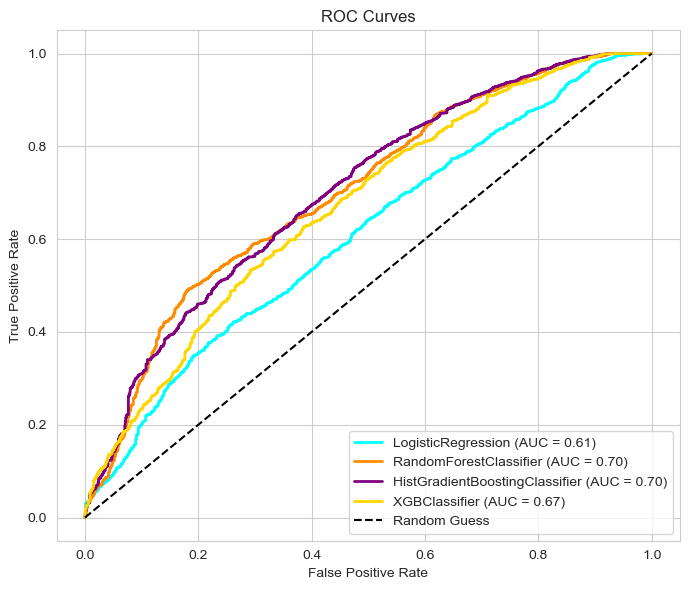

In [106]:
from itertools import cycle

models = [log_reg, rand_clas, hist_grad, xgb]
colors = cycle(['aqua', 'darkorange', 'purple', 'gold'])

plt.figure(figsize=(7, 6))
for model, color in zip(models, colors):
    prob = model.predict_proba(X_test)[:, 1]         
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{model.__class__.__name__} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess')   
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

ExactExplainer explainer: 4358it [00:47, 71.69it/s]                           


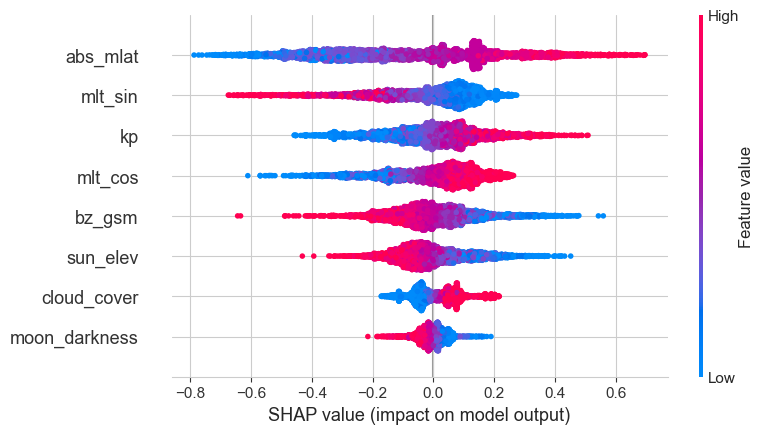

In [114]:
shap.plots.beeswarm(shap_values)

In [125]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [None, 10, 20],
    'min_samples_split':[2,5],
    "min_samples_leaf": [1, 5, 20],
    "max_features": ["sqrt", 0.5],
    'bootstrap': [True, False],
    'min_samples_leaf': [1, 2]

}

tscv = TimeSeriesSplit(n_splits=4)

grid_cv = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_cv.fit(X_train, y_train)

print("best params:", grid_cv.best_params_)
print("best CV AUC:", round(grid_cv.best_score_, 3))


Fitting 4 folds for each of 144 candidates, totalling 576 fits


KeyboardInterrupt: 

In [123]:
param_grid = {
    'n_estimators': [100, 200,],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_cv = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_cv.fit(X_train, y_train)

print("best params:", grid_cv.best_params_)
print("best CV AUC:", round(grid_cv.best_score_, 3))


Fitting 4 folds for each of 48 candidates, totalling 192 fits
best params: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
best CV AUC: 0.751


In [164]:

import shap

#for logistic_regression
explainer_log = shap.Explainer(log_reg.predict, X_test)
shap_values_log = explainer_log(X_test)



Fitting 4 folds for each of 54 candidates, totalling 216 fits
best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 200}
best CV AUC: 0.758


In [167]:



df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", utc=True)
df = df[~((df["see_aurora"] == True) & (df["sun_elev"] > 0))].sort_values("timestamp").reset_index(drop=True)

features = ["abs_mlat","kp","bz_gsm","cloud_cover","moon_darkness","mlt_sin","mlt_cos","sun_elev"]
df = df.dropna(subset=features + ["see_aurora"]).reset_index(drop=True)

X = df[features]
y = df["see_aurora"].astype(int)
tscv = TimeSeriesSplit(n_splits=4)

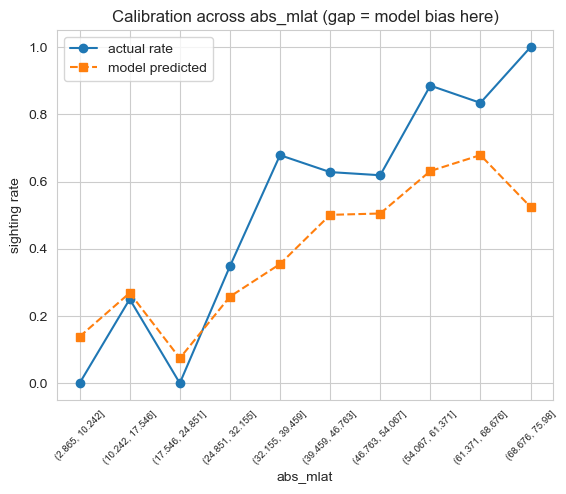

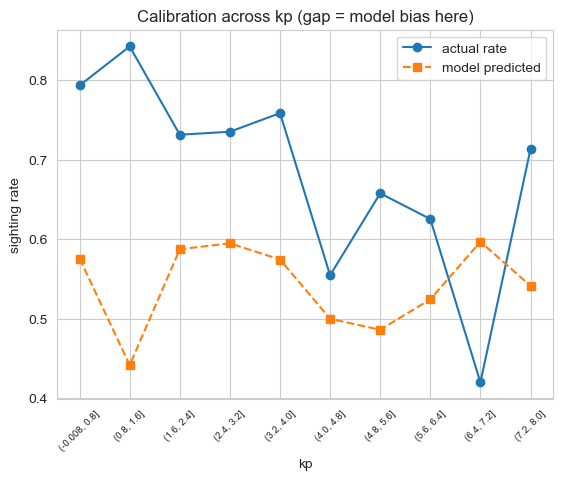

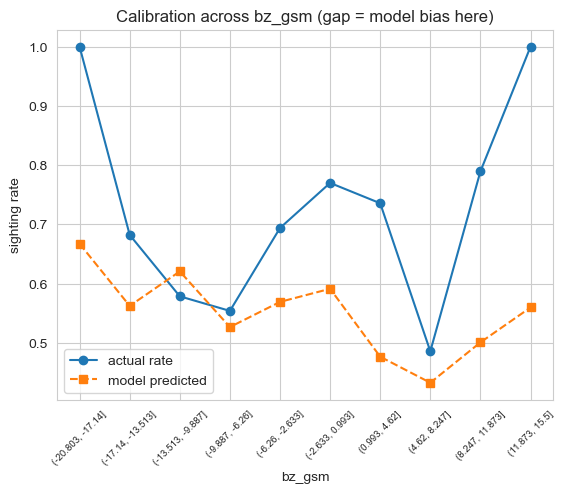

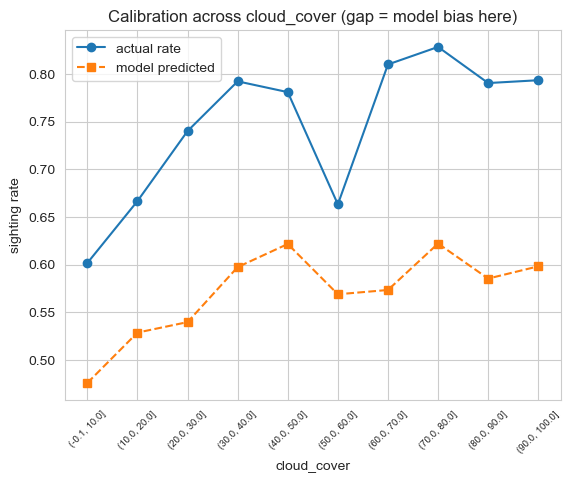

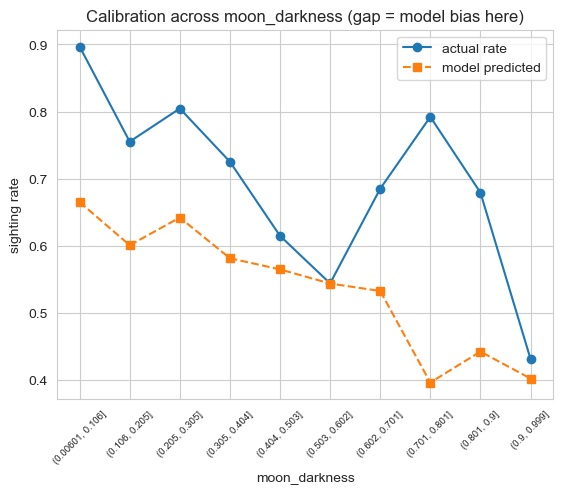

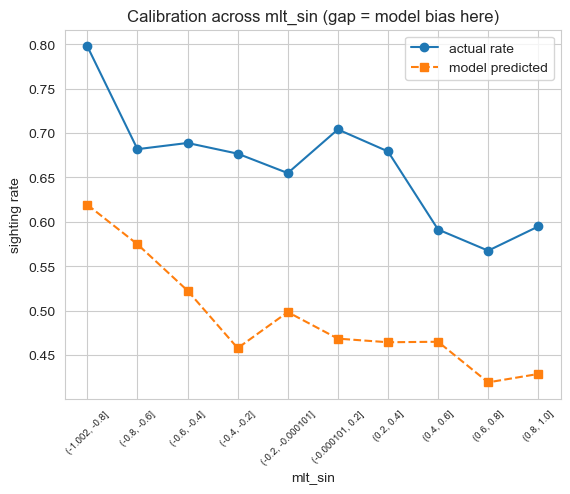

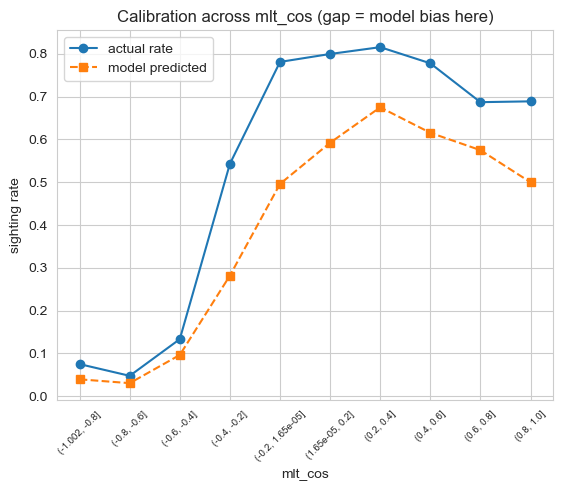

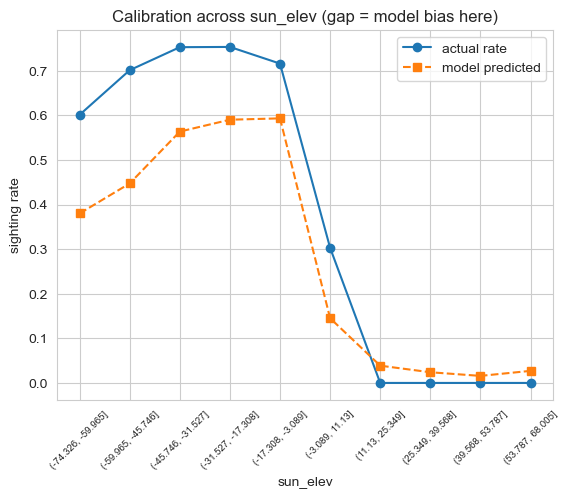

In [171]:
test = X_test.copy()
test["actual"] = y_test.values
test["pred"]   = model.predict_proba(X_test)[:, 1]

features= ['abs_mlat', 'kp', 'bz_gsm', 'cloud_cover', 'moon_darkness', 'mlt_sin', 'mlt_cos', 'sun_elev']

for feature in features:
    test["bin"] = pd.cut(test[feature], bins=10)
    g = test.groupby("bin", observed=True).agg(actual_rate=("actual","mean"),
                                            pred_rate=("pred","mean"),
                                            n=("actual","size"))

    plt.plot(range(len(g)), g["actual_rate"], "o-", label="actual rate")
    plt.plot(range(len(g)), g["pred_rate"],   "s--", label="model predicted")
    plt.xticks(range(len(g)), [str(b) for b in g.index], rotation=45, fontsize=7)
    plt.xlabel(feature); plt.ylabel("sighting rate"); plt.legend()
    plt.title(f"Calibration across {feature} (gap = model bias here)")
    plt.show()